# 05. 시각화 — 한글, 객체지향 API, 그리고 '틀린 그래프'

`legacy/Untitled.ipynb` 은 이런 코드로 차트를 만들었다.

```python
plt.figure(figsize=(10,10))
plt.title('vBrand and vPrice')          # 한글을 못 써서 영문 변수명 그대로
plt.bar(work_data['vBrand'], work_data['vPrice'])   # 400행을 그대로 bar 에
plt.savefig(vImg1)
```

문제 세 가지.
1. **한글 폰트 미설정** → 축 라벨을 한글로 쓸 수 없어 `vBrand` 같은 변수명을 그대로 노출
2. **집계하지 않은 원자료를 `bar` 에** → 같은 브랜드가 수십 번 겹쳐 그려지고, 마지막 값만 보인다
3. `plt.show()` 뒤 `savefig` → **빈 이미지**가 저장된다

## 학습 목표
1. 한글 폰트 설정과 마이너스 기호 문제
2. `plt.*` (상태 기반) vs `fig, ax` (객체지향) — 어느 쪽을 언제
3. 목적별 차트 고르기: bar / hist / scatter / box / line
4. **집계 후 정렬해서 그리기**
5. 저장: `savefig` 순서, `dpi`, `bbox_inches`
6. 여러 그래프를 한 화면에 (`subplots`)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "nbtools").is_dir())
sys.path.insert(0, str(ROOT))
from nbtools import use_korean_font  # noqa: E402

font = use_korean_font()
print("사용 폰트:", font)

clean_path = ROOT / "data" / "used_cars_clean.csv"
if not clean_path.exists():
    raise SystemExit("04 노트북을 먼저 실행해 data/used_cars_clean.csv 를 만드세요")
cars = pd.read_csv(clean_path)
cars.head(3)

사용 폰트: AppleGothic


,brand,model,year,age,distance_km,fuel,price_manwon,service
0,현대,투싼,2021,4,91000,디젤,1159,단순수리
1,테슬라,모델Y,2022,3,48000,전기,3685,-
2,제네시스,G80,2016,9,149000,하이브리드,1287,단순수리


## 1. 한글 폰트 — 안 하면 전부 두부(□)

matplotlib 기본 폰트(DejaVu Sans)에는 한글 글리프가 없다. 경고만 뜨고 그림은 그려지므로
**깨진 채로 보고서에 들어가기 쉽다.** `nbtools.use_korean_font()` 가 하는 일은 두 줄이다.

```python
matplotlib.rcParams["font.family"] = "AppleGothic"   # 또는 NanumGothic / Malgun Gothic
matplotlib.rcParams["axes.unicode_minus"] = False    # 음수 기호(−)가 없어 깨지는 별개 문제
```

/var/folders/1j/j1rqhk410dqfrv1_t4jjk_gw0000gn/T/ipykernel_14320/1245652331.py:7: UserWarning: Glyph 48652 (\N{HANGUL SYLLABLE BEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/1j/j1rqhk410dqfrv1_t4jjk_gw0000gn/T/ipykernel_14320/1245652331.py:7: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/1j/j1rqhk410dqfrv1_t4jjk_gw0000gn/T/ipykernel_14320/1245652331.py:7: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/1j/j1rqhk410dqfrv1_t4jjk_gw0000gn/T/ipykernel_14320/1245652331.py:7: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/1j/j1rqhk410dqfrv1_t4jjk_gw0000gn/T/ipykernel_14320/1245652331.py:7: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/1j/j1rqhk410dqfrv1_t4jjk_gw0000gn/T/ipykern

/Users/ogu/dev/jupyterTest/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ogu/dev/jupyterTest/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ogu/dev/jupyterTest/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50630 (\N{HANGUL SYLLABLE EOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ogu/dev/jupyterTest/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ogu/dev/jupyterTest/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph

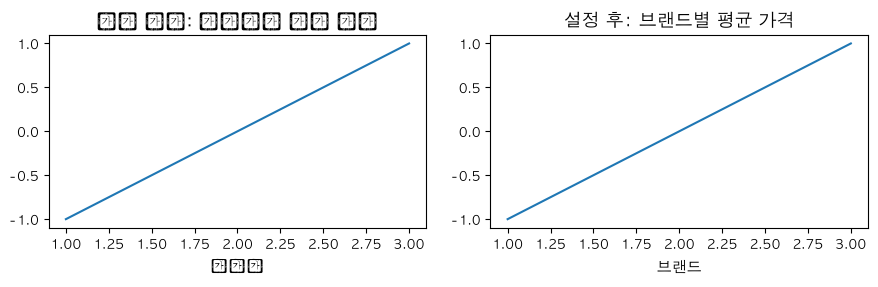

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, family, label in [(axes[0], "DejaVu Sans", "설정 없음"), (axes[1], font or "DejaVu Sans", "설정 후")]:
    ax.set_title(f"{label}: 브랜드별 평균 가격", fontfamily=family)
    ax.set_xlabel("브랜드", fontfamily=family)
    ax.plot([1, 2, 3], [-1, 0, 1])
    ax.tick_params(labelsize=9)
fig.tight_layout()

## 2. `plt.*` vs `fig, ax`

| 방식 | 특징 |
|---|---|
| `plt.bar(...)` | "현재 그림"에 그린다. 짧지만 여러 그래프를 다루면 어디에 그려질지 헷갈린다 |
| `fig, ax = plt.subplots(); ax.bar(...)` | 그릴 대상을 명시. **함수로 재사용**하기 쉽다 |

탐색할 땐 `plt.*`, 남길 코드는 `fig, ax` 를 쓰는 것이 실무 관행이다.

## 3. 원본이 만든 그래프의 문제 재현

집계하지 않은 400행을 그대로 `bar` 에 넘기면 어떻게 되는지 직접 본다.

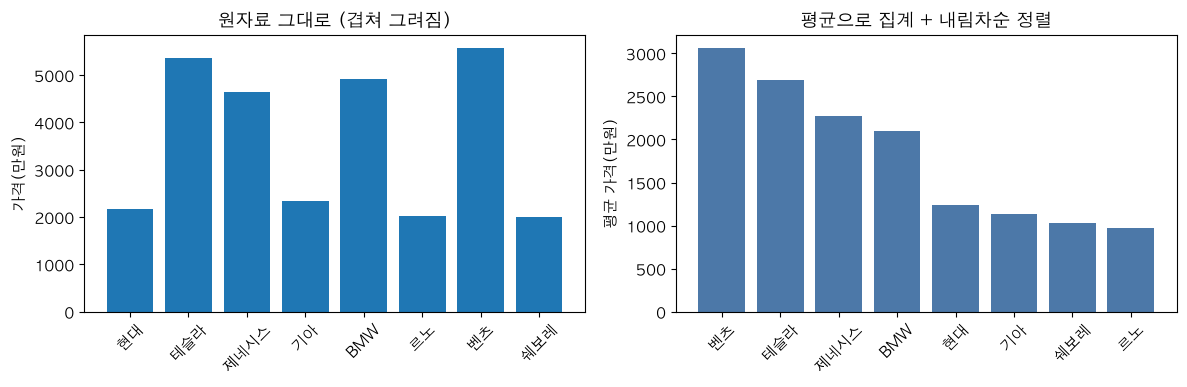

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cars["brand"], cars["price_manwon"])          # 원본 방식
axes[0].set_title("원자료 그대로 (겹쳐 그려짐)")
axes[0].set_ylabel("가격(만원)")
axes[0].tick_params(axis="x", rotation=45)

brand_mean = cars.groupby("brand")["price_manwon"].mean().sort_values(ascending=False)
axes[1].bar(brand_mean.index, brand_mean.values, color="#4C78A8")
axes[1].set_title("평균으로 집계 + 내림차순 정렬")
axes[1].set_ylabel("평균 가격(만원)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()

왼쪽은 같은 x 위치에 수십 개의 막대가 겹쳐 그려져 **사실상 최댓값 근처만 보인다**.
막대그래프는 "범주 하나에 값 하나"일 때만 의미가 있다 → 반드시 `groupby` 로 집계하고,
**정렬**해서 순위를 읽을 수 있게 한다.

## 4. 분포를 볼 때는 히스토그램

평균 하나로 요약하면 분포의 모양(치우침, 봉우리 개수)이 사라진다.

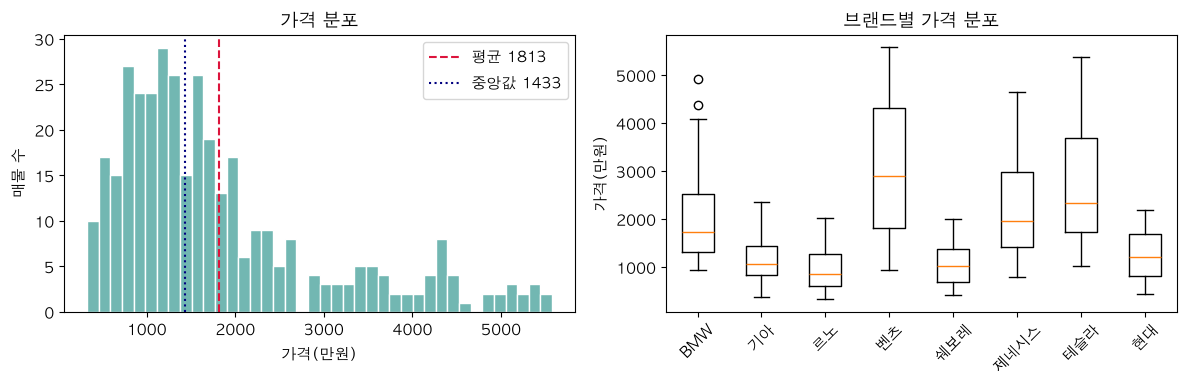

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cars["price_manwon"], bins=40, color="#72B7B2", edgecolor="white")
axes[0].axvline(cars["price_manwon"].mean(), color="crimson", linestyle="--", label=f"평균 {cars['price_manwon'].mean():.0f}")
axes[0].axvline(cars["price_manwon"].median(), color="navy", linestyle=":", label=f"중앙값 {cars['price_manwon'].median():.0f}")
axes[0].set(title="가격 분포", xlabel="가격(만원)", ylabel="매물 수")
axes[0].legend()

axes[1].boxplot(
    [group["price_manwon"].values for _, group in cars.groupby("brand")],
    tick_labels=sorted(cars["brand"].unique()),
)
axes[1].set(title="브랜드별 가격 분포", ylabel="가격(만원)")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()

가격 분포가 오른쪽으로 길게 늘어져(right-skewed) **평균이 중앙값보다 크다**.
이런 데이터에서 "평균 가격"만 보고하면 실제 매물의 체감과 어긋난다.

## 5. 두 변수의 관계 — 산점도

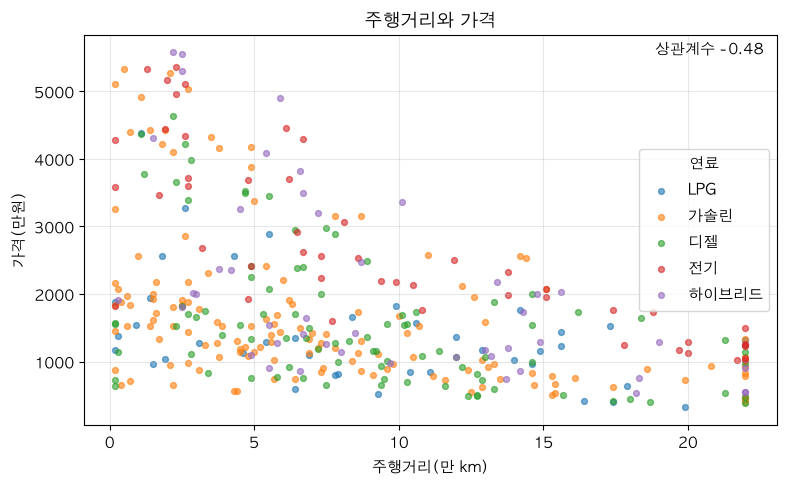

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for fuel, group in cars.groupby("fuel"):
    ax.scatter(group["distance_km"] / 10_000, group["price_manwon"], s=18, alpha=0.6, label=fuel)

ax.set(title="주행거리와 가격", xlabel="주행거리(만 km)", ylabel="가격(만원)")
ax.legend(title="연료")
ax.grid(alpha=0.3)

correlation = cars["distance_km"].corr(cars["price_manwon"])
ax.annotate(f"상관계수 {correlation:.2f}", xy=(0.98, 0.95), xycoords="axes fraction", ha="right")
fig.tight_layout()

## 6. 시간 축 — 연식별 추이

선 그래프는 **순서가 있는 축**에만 쓴다. 브랜드처럼 순서 없는 범주를 선으로 잇는 것은 오독을 부른다.

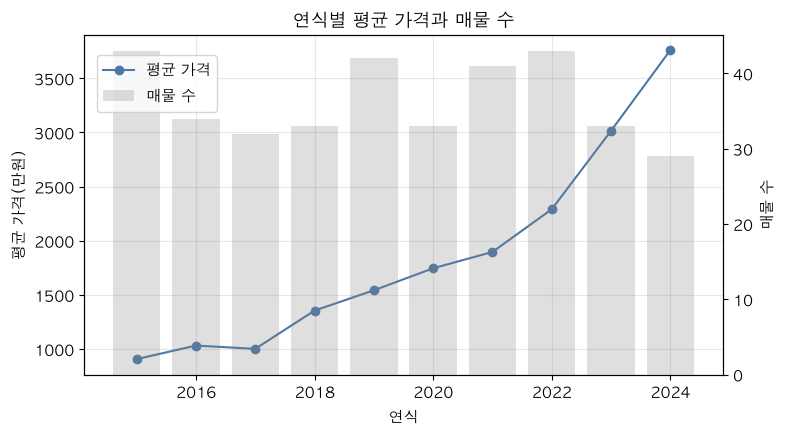

In [6]:
by_year = cars.groupby("year").agg(평균가격=("price_manwon", "mean"), 매물수=("price_manwon", "size"))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(by_year.index, by_year["평균가격"], marker="o", color="#4C78A8", label="평균 가격")
ax1.set(xlabel="연식", ylabel="평균 가격(만원)")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()                                   # 단위가 다른 값은 보조 축으로
ax2.bar(by_year.index, by_year["매물수"], alpha=0.25, color="gray", label="매물 수")
ax2.set_ylabel("매물 수")

ax1.set_title("연식별 평균 가격과 매물 수")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
fig.tight_layout()

## 7. 저장 — `show()` 다음에 `savefig()` 하면 빈 파일이 된다

`plt.show()` 는 현재 figure 를 화면에 내보내고 **비운다**. 그 뒤의 `savefig` 는 빈 캔버스를 저장한다.
노트북에서는 셀이 끝날 때 자동으로 렌더링되므로, **저장을 먼저** 하거나 `fig.savefig` 로 대상을 명시한다.

저장: outputs/brand_mean_price.png (34 KB)


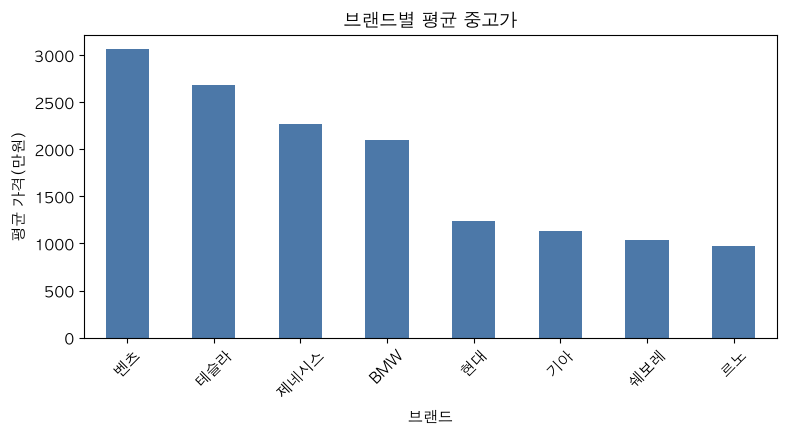

In [7]:
outputs = ROOT / "outputs"
outputs.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
brand_mean.plot(kind="bar", ax=ax, color="#4C78A8")      # pandas 도 ax 를 받는다
ax.set(title="브랜드별 평균 중고가", xlabel="브랜드", ylabel="평균 가격(만원)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

path = outputs / "brand_mean_price.png"
fig.savefig(path, dpi=150, bbox_inches="tight")          # fig 를 지정하므로 순서에 안전
print(f"저장: outputs/{path.name} ({path.stat().st_size / 1024:.0f} KB)")

* `dpi=150` — 화면용 100, 문서용 150~300
* `bbox_inches="tight"` — 회전된 라벨이 잘리는 것을 막는다
* 배경을 투명하게 하려면 `transparent=True`

## 8. 대시보드처럼 한 번에

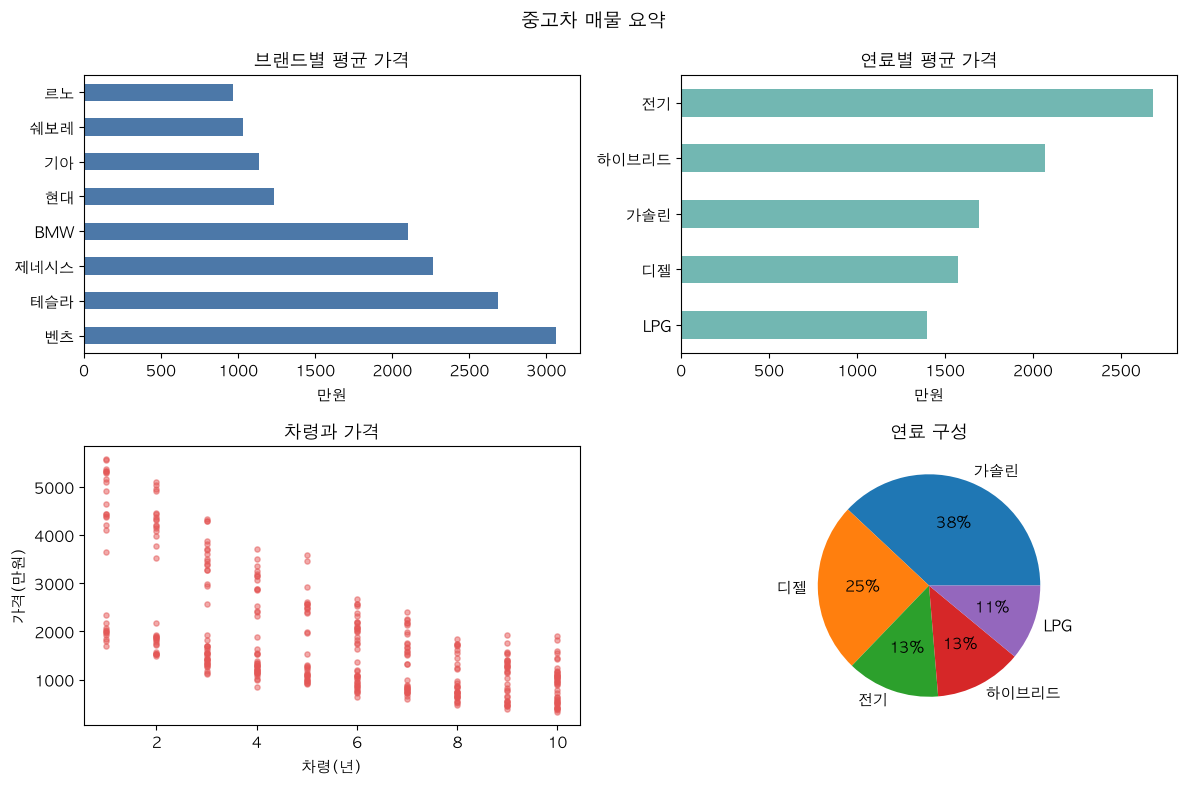

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

brand_mean.plot(kind="barh", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set(title="브랜드별 평균 가격", xlabel="만원", ylabel="")

cars.groupby("fuel")["price_manwon"].mean().sort_values().plot(kind="barh", ax=axes[0, 1], color="#72B7B2")
axes[0, 1].set(title="연료별 평균 가격", xlabel="만원", ylabel="")

axes[1, 0].scatter(cars["age"], cars["price_manwon"], s=14, alpha=0.5, color="#E45756")
axes[1, 0].set(title="차령과 가격", xlabel="차령(년)", ylabel="가격(만원)")

cars["fuel"].value_counts().plot(kind="pie", ax=axes[1, 1], autopct="%1.0f%%", ylabel="")
axes[1, 1].set(title="연료 구성")

fig.suptitle("중고차 매물 요약", fontsize=14)
fig.tight_layout()
fig.savefig(outputs / "dashboard.png", dpi=150, bbox_inches="tight")

> 원형 그래프는 **범주가 3~5개 이하이고 합이 100%일 때만** 쓴다. 조각이 많아지면 사람이 각도를
> 비교하지 못해 막대가 항상 낫다.

## 정리

| 실수 | 대응 |
|---|---|
| 한글이 □ 로 나옴 | `rcParams["font.family"]` + `axes.unicode_minus=False` |
| 원자료를 bar 에 | `groupby().mean()` 후 정렬해서 그리기 |
| 평균만 보고 | 히스토그램·박스플롯으로 분포 확인 |
| 순서 없는 범주를 선으로 | 선은 시간·순서 축에만 |
| `show()` 뒤 `savefig` | `fig.savefig(...)` 를 먼저 |
| 라벨 잘림 | `bbox_inches="tight"` |

다음: **06. 웹 스크래핑 기초**